# 🐍 Python Level 2 - Intermediate course
## Class 4 Mini-Project — Expenses Review Toolkit
### 📝 Practice Exercises Solutions

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">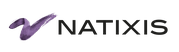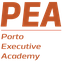</div>

---

---

The complete project, in the same seven parts as the brief. Run it top to bottom.

> 💡 This is **one** way to build it. Different function names, or a loop where this uses a
> comprehension, is not wrong and what matters is that every rule lives in a function and nothing
> is copied twice.

---

## Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "expenses.csv"
sns.set_style("whitegrid")

---
## Part 1 — Load the file

In [ ]:
# Part 1 - load it and look, before anything else
expenses = pd.read_csv(CSV_PATH)

print("Rows and columns :", expenses.shape)
print("Columns          :", list(expenses.columns))
print("Departments (raw):", expenses["department"].nunique())

---
## Part 2 — A cleaning function

In [ ]:
# Part 2 - the whole clean-up as one named job, so it can be re-run or reused
def clean_expenses(df):
    """Return a cleaned copy: no duplicates, tidy departments, no blank actuals."""
    clean = df.drop_duplicates().copy()
    clean["department"] = clean["department"].str.lower()
    clean = clean.drop(columns=["notes"])
    clean = clean.dropna(subset=["actual"])
    return clean


clean = clean_expenses(expenses)
print("Before:", expenses.shape)
print("After :", clean.shape)
print("Departments:", sorted(clean["department"].unique()))

---
## Part 3 — Two rule functions, tested on their own

In [ ]:
# Part 3 - small functions with one job each. Test them on values you can check
# by hand BEFORE letting them loose on 141 rows.
def variance_pct(budget, actual):
    """Return actual as a percentage of budget, to 1 decimal."""
    # float() first, so the answer is a plain number whether it is handed
    # ordinary values or a pandas total
    return round(float(actual) / float(budget) * 100, 1)


def classify_variance(used_pct, over_limit=110, under_limit=90):
    """Label a used percentage: OVER, under, or on budget."""
    if used_pct > over_limit:
        return "OVER"
    elif used_pct < under_limit:
        return "under"
    else:
        return "on budget"


print(variance_pct(1000, 1150))        # 115.0 - easy to check by hand
print(variance_pct(1000, 880))         # 88.0

print(classify_variance(115.0))
print(classify_variance(95.0))
print(classify_variance(88.0))
print(classify_variance(95.0, over_limit=94))    # the defaults can be overridden

---
## Part 4 — The summary, built with comprehensions

In [ ]:
# Part 4 - two groupby results, then one comprehension that reads them into a
# list of dicts. Sorted with a lambda key, biggest overspend first.
def summarise_by_department(df):
    """Return a list of dicts, one per department, worst overspend first."""
    budgets = df.groupby("department")["budget"].sum()
    actuals = df.groupby("department")["actual"].sum()

    rows = [
        {
            "group": department,
            "budget": int(budgets[department]),
            "actual": round(float(actuals[department]), 2),
            "used_pct": variance_pct(budgets[department], actuals[department]),
        }
        for department in budgets.index
    ]

    return sorted(rows, key=lambda row: row["used_pct"], reverse=True)


summary = summarise_by_department(clean)

for row in summary:
    print(row)

over_budget = {row["group"] for row in summary if row["used_pct"] > 100}
print()
print("Departments over budget:", sorted(over_budget))
print("Any department over 110%?", any(row["used_pct"] > 110 for row in summary))
print("All departments over 80%?", all(row["used_pct"] > 80 for row in summary))

---
## Part 5 — A reporting function

In [ ]:
# Part 5 - printing is its own job, kept apart from working the numbers out
def print_report(rows, label="department"):
    """Print the summary table, and a count of each status underneath."""
    counts = {"OVER": 0, "on budget": 0, "under": 0}

    print("EXPENSES REVIEW")
    print("-" * 58)
    print(f"{label:<12}{'budget':>12}{'actual':>12}{'used':>8}   status")
    print("-" * 58)

    for row in rows:
        status = classify_variance(row["used_pct"])
        counts[status] += 1
        print(f"{row['group']:<12}{row['budget']:>12,}"
              f"{row['actual']:>12,.2f}{row['used_pct']:>7.1f}%   {status}")

    print("-" * 58)
    for status in ["OVER", "on budget", "under"]:
        print(f"{status:<12}{counts[status]:>4}")


print_report(summary)

---
## Part 6 — A dashboard function

In [ ]:
# Part 6 - the charts are a job too, so they get a function and a filename
def draw_dashboard(df, rows, filename):
    """Draw a four-chart dashboard from the cleaned data and save it."""
    by_month = df.groupby("month")["actual"].sum().round(2)

    groups = [row["group"] for row in rows]
    used = [row["used_pct"] for row in rows]

    plt.figure(figsize=(11, 7))

    plt.subplot(2, 2, 1)
    plt.plot(by_month.index, by_month.values, marker="o", color="purple")
    plt.title("Actual spend by month")
    plt.ylabel("EUR")
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 2)
    plt.bar(groups, used, color="teal")
    plt.axhline(y=100, color="grey", linestyle="--")     # 100% = exactly on budget
    plt.title("Budget used by department")
    plt.ylabel("% of budget")
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 3)
    plt.hist(df["actual"], bins=12, color="teal")
    plt.title("Spread of individual amounts")
    plt.xlabel("EUR")
    plt.ylabel("How many lines")

    plt.subplot(2, 2, 4)
    plt.scatter(df["budget"], df["actual"], color="purple", alpha=0.6)
    plt.plot([0, 40000], [0, 40000], color="grey", linestyle="--")
    plt.title("Budget against actual")
    plt.xlabel("Budget (EUR)")
    plt.ylabel("Actual (EUR)")

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print("Saved", filename)


draw_dashboard(clean, summary, "expenses_review.png")

---
## Part 7 — The whole thing, as a list of calls

In [ ]:
# Part 7 - this is the payoff. Every rule lives in a function, so the program
# itself reads as a short list of steps.
def run_review(csv_path, chart_name="expenses_review.png"):
    """Run the whole review: load, clean, summarise, report, chart."""
    raw = pd.read_csv(csv_path)
    tidy = clean_expenses(raw)
    rows = summarise_by_department(tidy)

    print_report(rows)
    print()
    draw_dashboard(tidy, rows, chart_name)

    return rows


results = run_review(CSV_PATH)
print()
print("Worst department:", results[0]["group"], f"({results[0]['used_pct']}%)")

---
## Stretch goal 1 — The same review, per category

In [ ]:
# The summary function works on any grouping if the column name is a parameter
def summarise_by(df, column):
    """Return a list of dicts summarising the data by any column."""
    budgets = df.groupby(column)["budget"].sum()
    actuals = df.groupby(column)["actual"].sum()

    rows = [
        {
            "group": group,
            "budget": int(budgets[group]),
            "actual": round(float(actuals[group]), 2),
            "used_pct": variance_pct(budgets[group], actuals[group]),
        }
        for group in budgets.index
    ]
    return sorted(rows, key=lambda row: row["used_pct"], reverse=True)


category_summary = summarise_by(clean, "category")
print_report(category_summary, label="category")

---
## Stretch goal 2 — Tighter limits

In [ ]:
# Because the limits are parameters with defaults, one call changes the whole
# picture without touching classify_variance() itself
for row in category_summary:
    strict = classify_variance(row["used_pct"], over_limit=100, under_limit=97)
    print(f"{row['group']:<12}{row['used_pct']:>7.1f}%   {strict}")

---
## Stretch goal 3 — Tighter limits

In [ ]:
summary_df = pd.DataFrame(category_summary)
summary_df.to_csv("expenses_summary.csv", index=False)

---

### 🎉 What this shows

Compare part 7 with the Level 1 project. There, the whole review was one long cell. Here it is
five functions and a list of calls and that difference is the whole of Level 2.

| Part | What it used | From |
|------|--------------|------|
| 1 | `read_csv`, `.shape`, `.nunique()` | L1C3 |
| 2 | A function wrapping the whole clean-up | L2C1 |
| 3 | Two small functions, default arguments, tested alone | L2C1 |
| 4 | A **list comprehension** building dicts, `sorted` with a **lambda**, a **set comprehension**, `any`/`all` | L2C2 |
| 5 | A function that only prints, `+=`, f-strings with alignment | L2C1, L1C1 |
| 6 | `subplot`, four chart types, `axhline`, `savefig` | L2C3 |
| 7 | Functions calling functions, a default argument, returning a value | L2C1 |

Four things worth taking away:

1. **Test a function on values you can check by hand.** Part 3 proves `variance_pct(1000, 1150)`
   is `115.0` before it is trusted with 141 rows. Debugging one function is easy; debugging a
   whole notebook is not.
2. **Keep working things out apart from printing them.** `summarise_by_department()` returns
   data; `print_report()` displays it. That is why the stretch goal could reuse the report for
   categories without changing a line of it.
3. **Put the limits in parameters, not in the middle of an `if`.** Stretch goal 2 changes the
   entire verdict with one call, because `classify_variance` takes its limits as arguments.
4. **The main program should read like a table of contents.** If part 7 needs a comment to
   explain what it does, the function names are wrong.